In [2]:
import sys
import os
import numpy as np

import matplotlib.pyplot as plt
import importlib

sys.path.insert(1, f'{os.getcwd()}/../../../analysis')
import calc_water_wire_path

In [3]:
top_path = "/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/inputs/gromacs_c/seg_06.gro"
trj_path = "/home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/run_c/1/mtd_seg_01_aligned.all.c.1.xtc"

In [4]:
importlib.reload(calc_water_wire_path)
# queries1 = ["resname HOH and element O"]
# pcs1, paths1 = calc_water_wire_path.save_wire_pc(trj_path, top_path, "aac1", "aac1-atp-test", queries1)

queries2 = ["resname HOH and element O",
            "resname ATP and not element H"
            "resname POT",
            "resname CLA"]
pcs2c, pcs2m, pcs_cm, paths2 = calc_water_wire_path.save_wire_pc(trj_path, top_path, "aac1", "aac1-atp-test-2", queries2)

trajectory = /home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/run_c/1/mtd_seg_01_aligned.all.c.1.xtc
topology = /home/jonathan/Documents/grabelab/aac1-nt-transport/metadynamics/run4/inputs/gromacs_c/seg_06.gro
trajectory has 1153 frames
14634 waters selected
0
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150


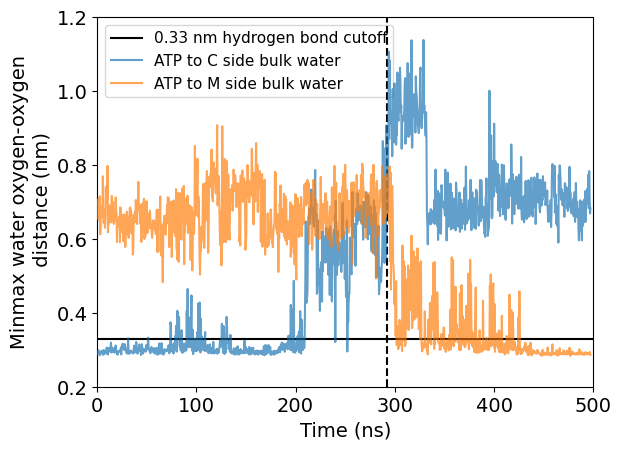

In [5]:

plt.rcParams['font.size'] = 14
times = np.arange(len(pcs2c)) * 497.6/len(pcs2c)

plt.axhline(0.33, color="black", zorder=0)

plt.plot(times, pcs2c, alpha = 0.7, zorder=99)#, linewidth=2)
plt.plot(times, pcs2m, alpha = 0.7, zorder=99)#, linewidth=2)
#plt.plot(times, pcs_cm, alpha = 0.7, zorder=100, color="black", linewidth=1/2)

#h-bond threshold
plt.axhline(0.33, color="black", alpha = 0.15, zorder=99)

#
plt.axvline(676 * 497.6/len(pcs2c), color="black", linestyle="--", zorder=10)

plt.ylim(0.2,1.2)
plt.xlim(0,500)

plt.xlabel("Time (ns)")
plt.ylabel("Minmax water oxygen-oxygen\n distance (nm)")
plt.legend(["0.33 nm hydrogen bond cutoff", "ATP to C side bulk water", "ATP to M side bulk water"], fontsize=11)

plt.savefig("aac1-atp-water-wire-pc.png", dpi=600, bbox_inches="tight")


In [6]:
most_occluded_frame = np.argmax(np.array(pcs2c) + np.array(pcs2m))
print(most_occluded_frame)
print(most_occluded_frame * 497.6/len(pcs2c))

683
294.76218560277533


In [26]:
print(np.argsort(np.array(pcs2c) + np.array(pcs2m))[-30:])
print(615 * 497.6/len(pcs2c))

[737 756 692 730 684 508 728 682 713 742 729 748 746 718 667 739 677 689
 687 669 744 680 675 688 676 685 690 734 681 683]
265.4154379878578


In [27]:
print((np.array(pcs2c) + np.array(pcs2m))[676])
print(676 * 497.6/len(pcs2c))

1.6658257445101263
291.74119687771037


In [7]:
# pc1 = np.stack(pcs1)
# plt.plot(pcs1)

In [8]:
# pc2 = np.stack(pcs2)
# plt.plot(pcs2)

In [9]:
# plt.plot(pcs1)
# plt.plot(pcs2)

In [10]:
#see frame 677 for an example occluded state
